<a href="https://colab.research.google.com/github/AdhvikaECE536/AdhvikaECE536/blob/main/grp57.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORT

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

#LOAD DATA

In [64]:

df = pd.read_excel('AirQualityUCI.xlsx')
print("DATASET LOADED")
print(f"Shape: {df.shape}  →  {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumn names:")
print(list(df.columns))
print(df.head())

DATASET LOADED
Shape: (9357, 15)  →  9357 rows, 15 columns

Column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.25    131.0       1140.00    114.0       1554.50      1074.00   
3         948.25    172.0       

#ERROR CODE VALUES: -200


In [51]:
df.replace(-200, np.nan, inplace=True)

# Fill NaN with 0
df.fillna(0, inplace=True)

print("Done. All -200 values are now 0.")

Done. All -200 values are now 0.


#DATA VALIDITY REPORT

In [65]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
total_rows = len(df)

validity_data = []
for col in numeric_cols:
    zero_count   = (df[col] == 0).sum()
    valid_count  = total_rows - zero_count
    zero_pct     = (zero_count / total_rows) * 100
    valid_pct    = 100 - zero_pct
    validity_data.append({
        'Column': col,
        'Total Rows': total_rows,
        'Valid (non-zero)': valid_count,
        'Zero Count': zero_count,
        '% Valid': round(valid_pct, 2),
        '% Zero': round(zero_pct, 2)
    })

validity_df = pd.DataFrame(validity_data)
print(validity_df.to_string(index=False))

# Flag columns with more than 50% zeros — these are unreliable
bad_cols = validity_df[validity_df['% Zero'] > 50]['Column'].tolist()
print(f"\n⚠ Columns with >50% zero values (unreliable): {bad_cols}")

       Column  Total Rows  Valid (non-zero)  Zero Count  % Valid  % Zero
       CO(GT)        9357              9357           0    100.0     0.0
  PT08.S1(CO)        9357              9357           0    100.0     0.0
     NMHC(GT)        9357              9357           0    100.0     0.0
     C6H6(GT)        9357              9357           0    100.0     0.0
PT08.S2(NMHC)        9357              9357           0    100.0     0.0
      NOx(GT)        9357              9357           0    100.0     0.0
 PT08.S3(NOx)        9357              9357           0    100.0     0.0
      NO2(GT)        9357              9357           0    100.0     0.0
 PT08.S4(NO2)        9357              9357           0    100.0     0.0
  PT08.S5(O3)        9357              9357           0    100.0     0.0
            T        9357              9357           0    100.0     0.0
           RH        9357              9357           0    100.0     0.0
           AH        9357              9357        

#HANDLING MISSING VALUES

In [66]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness per column (positive = right-skewed, higher = more skewed):")
print(skewness.round(2))


# Show a quick comparison: mean vs median for CO(GT)
co_mean   = df['CO(GT)'].mean()
co_median = df['CO(GT)'].median()
print(f"CO(GT) example → Mean: {co_mean:.3f}  |  Median: {co_median:.3f}")
print("The median is lower and more representative of a typical hour.")

# Re-fill zeros with median of non-zero values for better model accuracy
print("\nRe-filling zeros with column median (non-zero median):")
sensor_cols = [c for c in numeric_cols if c not in ['NMHC(GT)']]
for col in sensor_cols:
    non_zero_median = df[col][df[col] != 0].median()
    count_replaced  = (df[col] == 0).sum()
    if count_replaced > 0:
        df[col] = df[col].replace(0, non_zero_median)
        print(f"  {col}: replaced {count_replaced} zeros with median = {non_zero_median:.3f}")

Skewness per column (positive = right-skewed, higher = more skewed):
NMHC(GT)         4.08
NOx(GT)          0.83
PT08.S5(O3)     -0.03
PT08.S3(NOx)    -0.38
PT08.S2(NMHC)   -0.79
NO2(GT)         -1.23
PT08.S4(NO2)    -1.24
CO(GT)          -1.67
PT08.S1(CO)     -1.72
RH              -3.93
T               -4.45
C6H6(GT)        -4.51
AH              -4.75
dtype: float64
CO(GT) example → Mean: -34.208  |  Median: 1.500
The median is lower and more representative of a typical hour.

Re-filling zeros with column median (non-zero median):


#DROPPING UNRELIABLE COLUMNS

In [54]:
if 'NMHC(GT)' in df.columns:
    df.drop(columns=['NMHC(GT)'], inplace=True)
    print("Dropped: NMHC(GT)  (>90% was sensor-failure data)")

Dropped: NMHC(GT)  (>90% was sensor-failure data)


#EXTRACT FEATURES: USING PARSING

In [55]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'].astype(str), errors='coerce')

df['Hour']      = df['Time'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Month']     = df['Date'].dt.month

print("Extracted: Hour, DayOfWeek, Month")
print(f"  Hour range     : {df['Hour'].min()} to {df['Hour'].max()}")
print(f"  Months covered : {sorted(df['Month'].unique())}")

df.drop(columns=['Date', 'Time'], inplace=True)
print("Dropped raw Date and Time columns (non-numeric, already extracted)")

Extracted: Hour, DayOfWeek, Month
  Hour range     : 0 to 23
  Months covered : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Dropped raw Date and Time columns (non-numeric, already extracted)


#CREATE AQI TARGET LABELS FROM CO(GT)

In [56]:
def get_aqi_label(co):
    if co < 2:    return 'Good'
    elif co < 5:  return 'Moderate'
    elif co < 10: return 'Unhealthy'
    else:         return 'Hazardous'

df['AQI_Class'] = df['CO(GT)'].apply(get_aqi_label)

print("AQI class distribution:")
dist = df['AQI_Class'].value_counts()
for label, count in dist.items():
    pct = count / len(df) * 100
    print(f"  {label:12s}: {count:5d} rows  ({pct:.1f}%)")

le = LabelEncoder()
df['AQI_Label'] = le.fit_transform(df['AQI_Class'])
print(f"\nEncoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

AQI class distribution:
  Good        :  5808 rows  (62.1%)
  Moderate    :  3167 rows  (33.8%)
  Unhealthy   :   377 rows  (4.0%)
  Hazardous   :     5 rows  (0.1%)

Encoding: {'Good': np.int64(0), 'Hazardous': np.int64(1), 'Moderate': np.int64(2), 'Unhealthy': np.int64(3)}


#FEATURE SCALING & TRAIN/TEST SPLIT

In [57]:
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ['AQI_Label']]
X = df[feature_cols]
y = df['AQI_Label']

print(f"Features used ({len(feature_cols)}): {feature_cols}")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

Features used (15): ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'DayOfWeek', 'Month']
Train: 7485 rows  |  Test: 1872 rows


#TRAIN & COMPARE 5 MODELS

In [58]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'AdaBoost':      AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'SVM':           SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'Naive Bayes':   GaussianNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    cv  = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
    results[name] = {'Accuracy': acc, 'F1 Macro': f1, 'CV Score': cv,
                     'model': model, 'y_pred': y_pred}
    print(f"{name:20s} → Accuracy: {acc:.4f}  F1: {f1:.4f}  CV: {cv:.4f}")

print("\nSummary (sorted by Accuracy):")
summary = pd.DataFrame({k: {m: v for m, v in v.items() if m not in ['model', 'y_pred']}
                         for k, v in results.items()}).T
print(summary.sort_values('Accuracy', ascending=False).round(4))

Random Forest        → Accuracy: 1.0000  F1: 1.0000  CV: 0.9982
AdaBoost             → Accuracy: 0.9594  F1: 0.4860  CV: 0.9599
SVM                  → Accuracy: 0.9770  F1: 0.7154  CV: 0.9480
KNN                  → Accuracy: 0.9215  F1: 0.9205  CV: 0.8366
Naive Bayes          → Accuracy: 0.8643  F1: 0.8513  CV: 0.8603

Summary (sorted by Accuracy):
               Accuracy  F1 Macro  CV Score
Random Forest    1.0000    1.0000    0.9982
SVM              0.9770    0.7154    0.9480
AdaBoost         0.9594    0.4860    0.9599
KNN              0.9215    0.9205    0.8366
Naive Bayes      0.8643    0.8513    0.8603


#HYPERPARAMETER TUNING

In [60]:
param_dist = {
    'n_estimators':      [50, 100, 150, 200],
    'max_depth':         [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}


rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1          # prints progress so you know it's running
)
rand_search.fit(X_train, y_train)

print("\nBest parameters:", rand_search.best_params_)
print("Best CV F1 score:", round(rand_search.best_score_, 4))

best_rf     = rand_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print("\nTuned Random Forest — Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 15}
Best CV F1 score: 0.8733

Tuned Random Forest — Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00      1162
   Hazardous       1.00      1.00      1.00         1
    Moderate       1.00      1.00      1.00       634
   Unhealthy       1.00      1.00      1.00        75

    accuracy                           1.00      1872
   macro avg       1.00      1.00      1.00      1872
weighted avg       1.00      1.00      1.00      1872



#VISUALIZATIONS

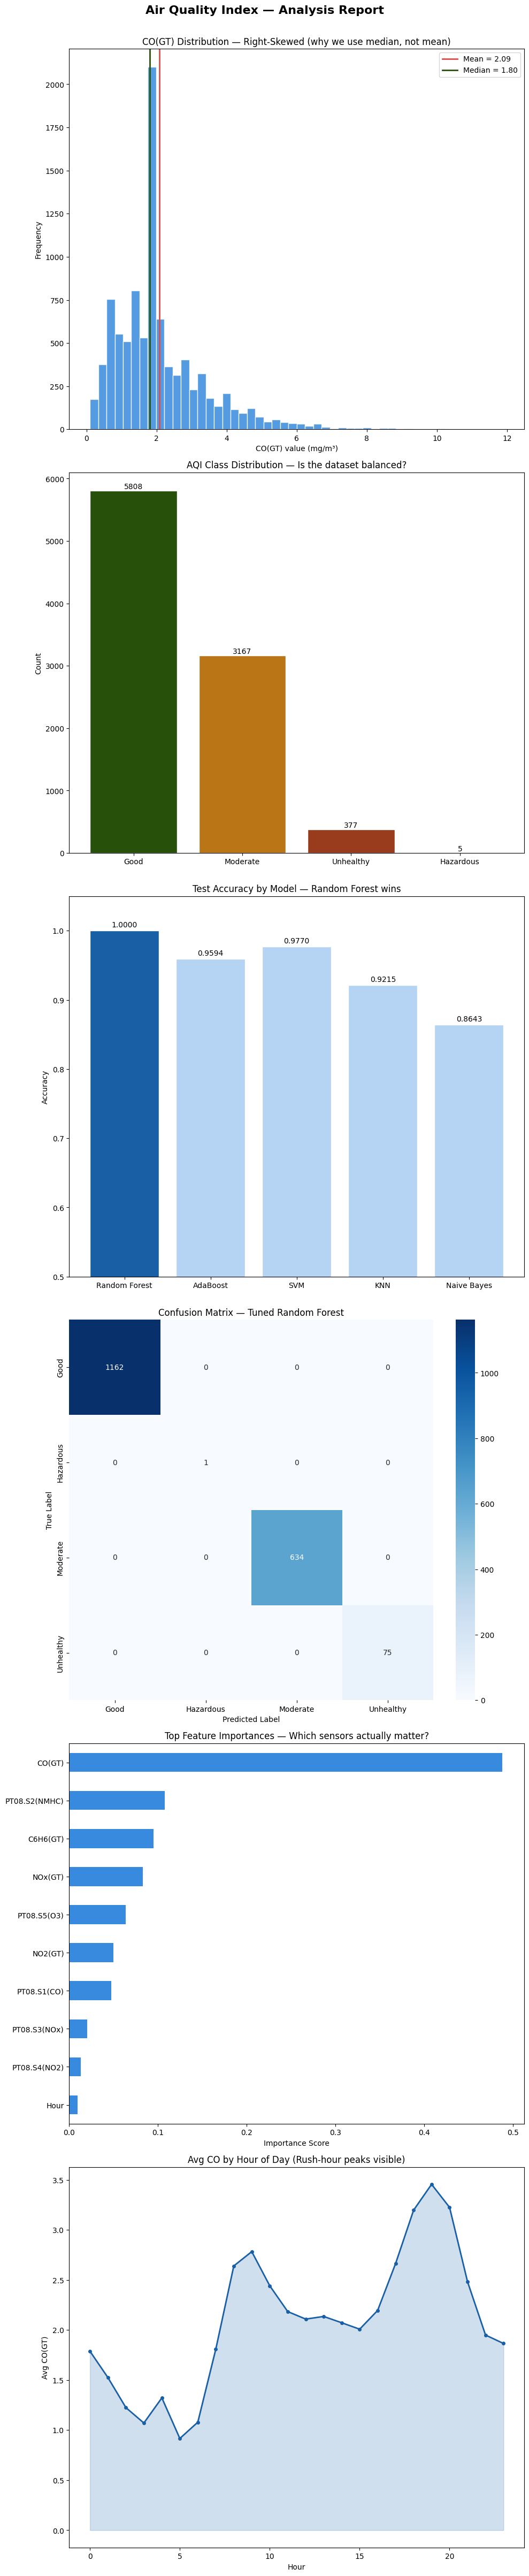


Plot saved as aqi_report.png


In [61]:
names  = list(results.keys())
accs   = [results[n]['Accuracy'] for n in names]
colors = ['#185FA5' if n == 'Random Forest' else '#B5D4F4' for n in names]

fig, axes = plt.subplots(6, 1, figsize=(10, 48))
fig.suptitle('Air Quality Index — Analysis Report',
             fontsize=16, fontweight='bold', y=1.002)

# 1. CO(GT) distribution — why median over mean
ax1 = axes[0]
co_vals = df['CO(GT)'][df['CO(GT)'] > 0]
ax1.hist(co_vals, bins=50, color='#378ADD', edgecolor='white', alpha=0.85)
ax1.axvline(co_vals.mean(),   color='#E24B4A', linewidth=2, label=f'Mean = {co_vals.mean():.2f}')
ax1.axvline(co_vals.median(), color='#27500A', linewidth=2, label=f'Median = {co_vals.median():.2f}')
ax1.set_xlabel('CO(GT) value (mg/m³)')
ax1.set_ylabel('Frequency')
ax1.set_title('CO(GT) Distribution — Right-Skewed (why we use median, not mean)')
ax1.legend(fontsize=10)

# 2. AQI class distribution
ax2 = axes[1]
class_colors = {'Good': '#27500A', 'Moderate': '#BA7517',
                'Unhealthy': '#993C1D', 'Hazardous': '#A32D2D'}
aqi_counts = df['AQI_Class'].value_counts()
bars = ax2.bar(aqi_counts.index, aqi_counts.values,
               color=[class_colors[c] for c in aqi_counts.index], edgecolor='white')
ax2.set_title('AQI Class Distribution — Is the dataset balanced?')
ax2.set_ylabel('Count')
for bar, (label, val) in zip(bars, aqi_counts.items()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha='center', fontsize=10)

# 3. Model accuracy comparison
ax3 = axes[2]
bars3 = ax3.bar(names, accs, color=colors, edgecolor='white')
ax3.set_ylim(0.5, 1.05)
ax3.set_title('Test Accuracy by Model — Random Forest wins')
ax3.set_ylabel('Accuracy')
for bar, val in zip(bars3, accs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=10)

# 4. Confusion matrix
ax4 = axes[3]
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax4.set_title('Confusion Matrix — Tuned Random Forest')
ax4.set_ylabel('True Label')
ax4.set_xlabel('Predicted Label')

# 5. Feature importances
ax5 = axes[4]
fi = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
fi.tail(10).plot(kind='barh', ax=ax5, color='#378ADD')
ax5.set_title('Top Feature Importances — Which sensors actually matter?')
ax5.set_xlabel('Importance Score')

# 6. Average CO by hour of day
ax6 = axes[5]
hourly = df.groupby('Hour')['CO(GT)'].mean()
ax6.plot(hourly.index, hourly.values, color='#185FA5', linewidth=2,
         marker='o', markersize=4)
ax6.fill_between(hourly.index, hourly.values, alpha=0.2, color='#185FA5')
ax6.set_title('Avg CO by Hour of Day (Rush-hour peaks visible)')
ax6.set_xlabel('Hour')
ax6.set_ylabel('Avg CO(GT)')

plt.tight_layout()
plt.savefig('aqi_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as aqi_report.png")

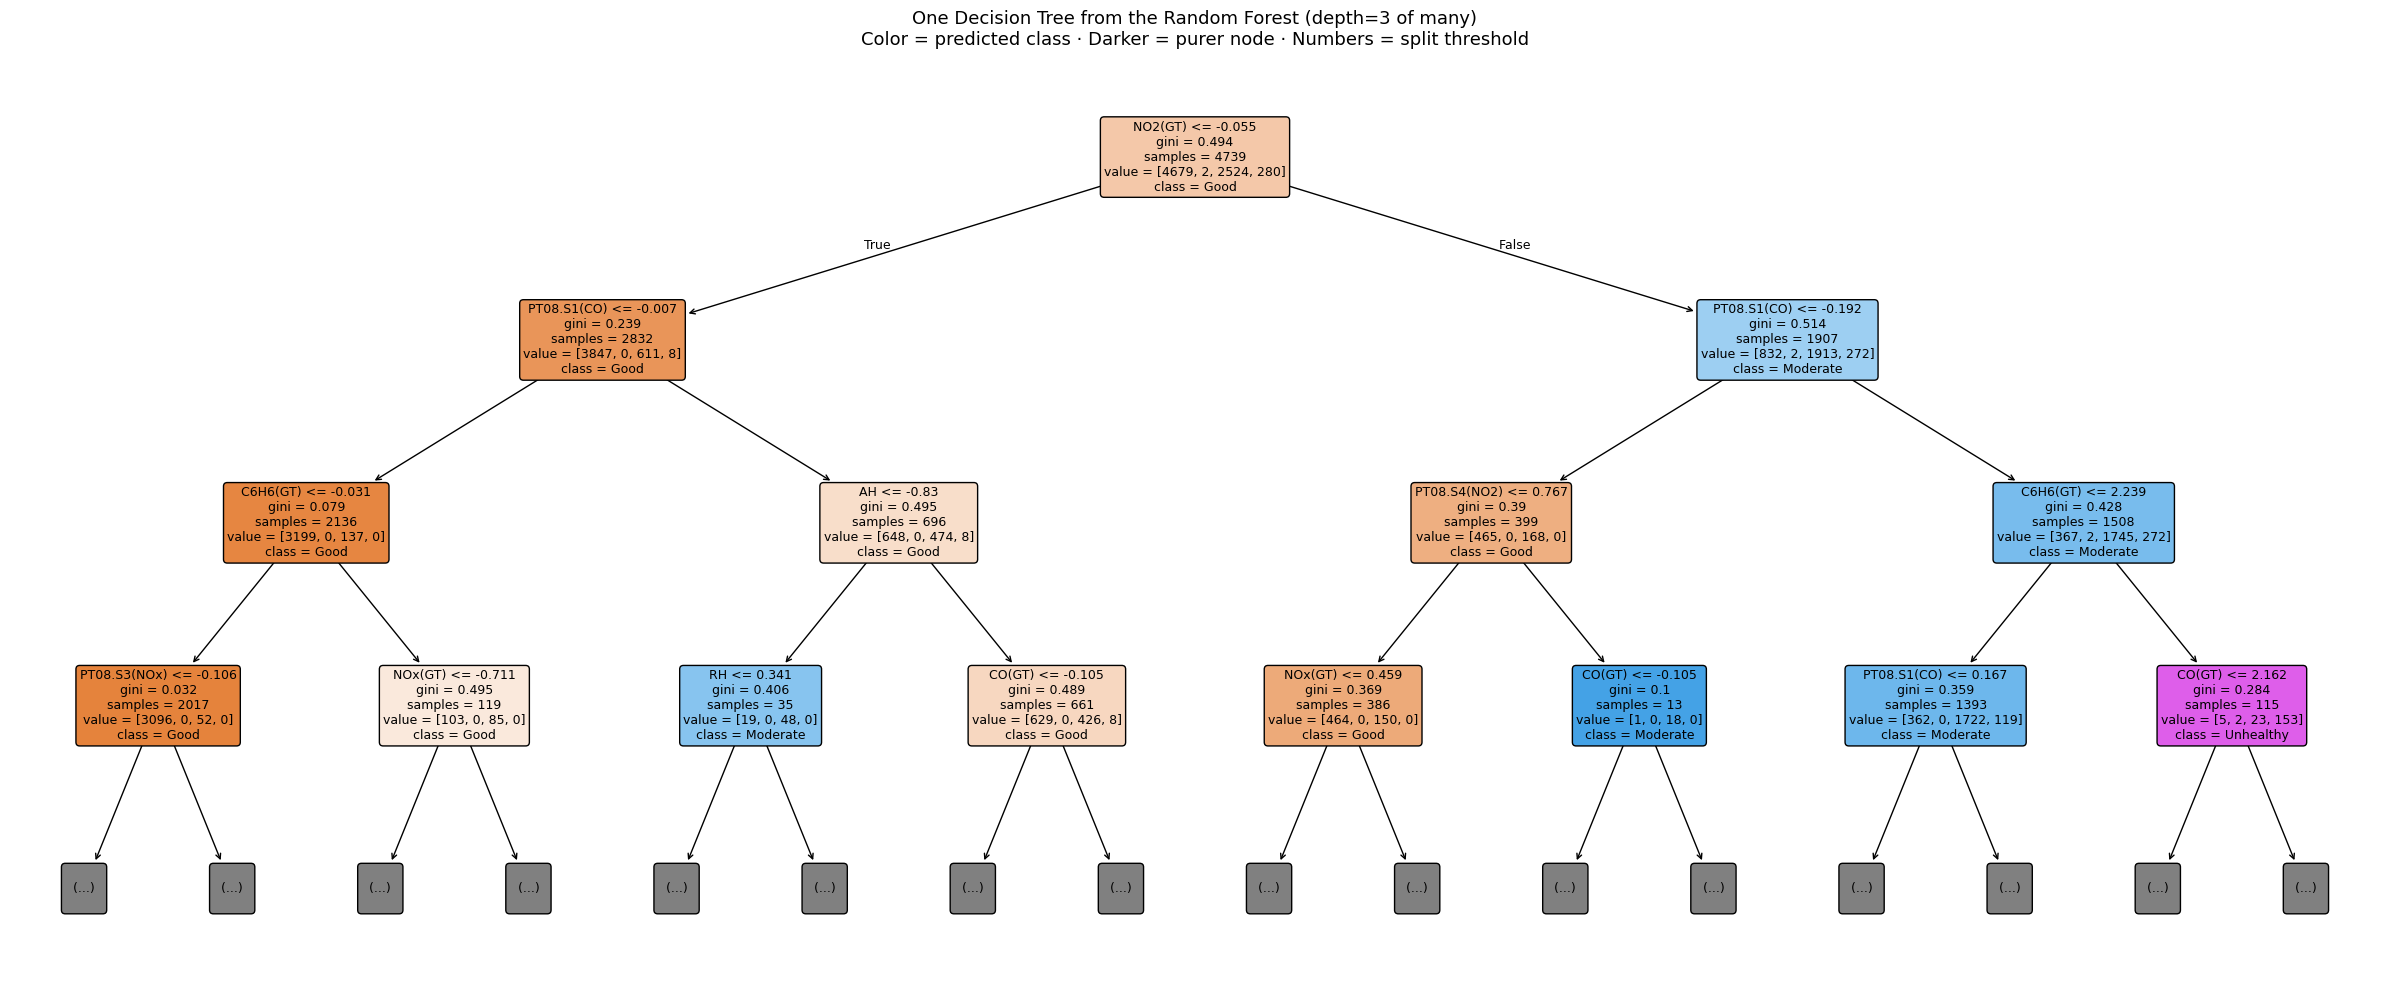

Tree plot saved as random_forest_tree.png


In [62]:
from sklearn.tree import export_graphviz, plot_tree


fig_tree, ax_tree = plt.subplots(figsize=(24, 10))

plot_tree(
    best_rf.estimators_[0],   # pull the first tree out of the forest
    max_depth=3,              # only show 3 levels — deeper = unreadable
    feature_names=feature_cols,
    class_names=le.classes_,
    filled=True,              # color nodes by majority class
    rounded=True,
    fontsize=9,
    ax=ax_tree
)

ax_tree.set_title(
    'One Decision Tree from the Random Forest (depth=3 of many)\n'
    'Color = predicted class · Darker = purer node · Numbers = split threshold',
    fontsize=13, pad=15
)

plt.tight_layout()
plt.savefig('random_forest_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tree plot saved as random_forest_tree.png")


#ADDRESSING how each pollutant varies across AQI classes

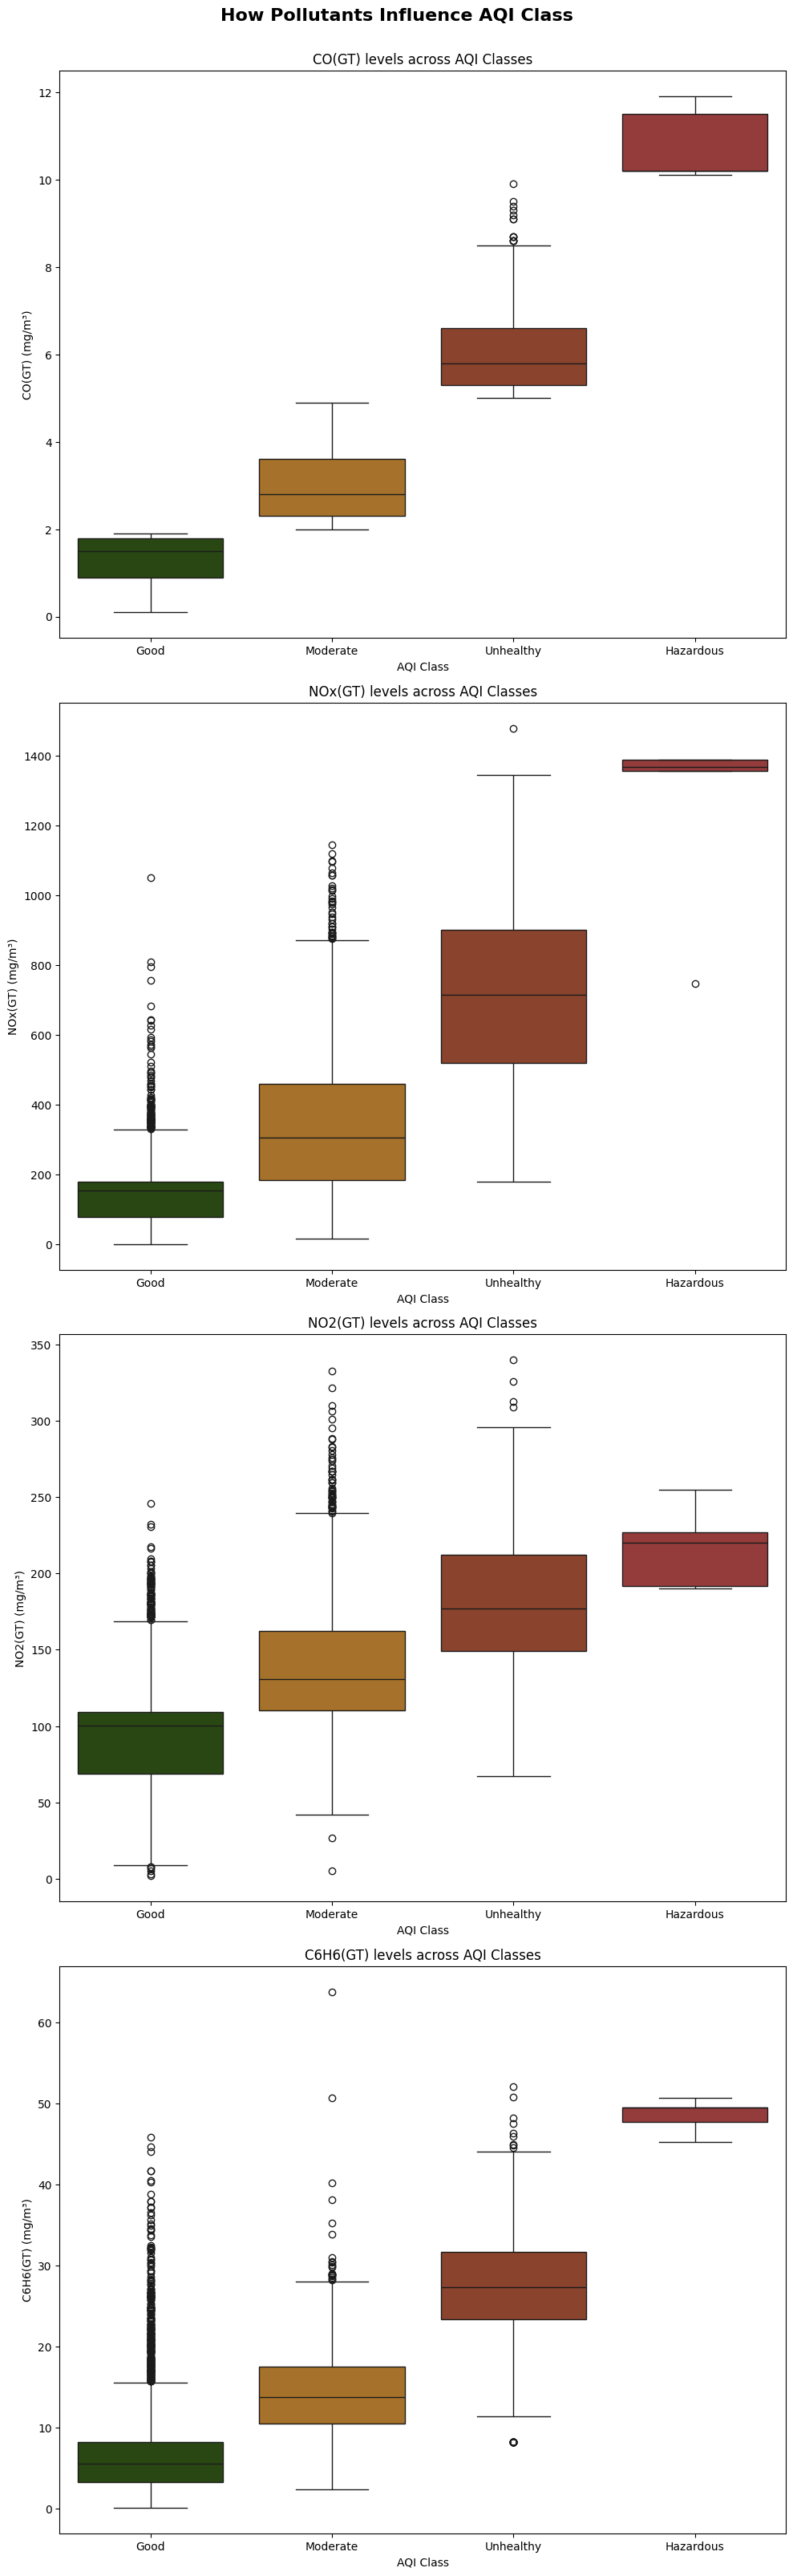

Saved as pollutant_influence.png


In [63]:
key_pollutants = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)']

fig2, axes2 = plt.subplots(4, 1, figsize=(10, 32))
fig2.suptitle('How Pollutants Influence AQI Class',
              fontsize=16, fontweight='bold', y=1.002)

order = ['Good', 'Moderate', 'Unhealthy', 'Hazardous']
palette = {'Good': '#27500A', 'Moderate': '#BA7517',
           'Unhealthy': '#993C1D', 'Hazardous': '#A32D2D'}

for i, col in enumerate(key_pollutants):
    sns.boxplot(
        data=df, x='AQI_Class', y=col,
        order=order, palette=palette, ax=axes2[i]
    )
    axes2[i].set_title(f'{col} levels across AQI Classes')
    axes2[i].set_xlabel('AQI Class')
    axes2[i].set_ylabel(f'{col} (mg/m³)')

plt.tight_layout()
plt.savefig('pollutant_influence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as pollutant_influence.png")